### 가설 검정 및 분석

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # array에 최적화 되어 있음

import seaborn as sns # DF에 최적화 되어 있음
from scipy import stats

In [4]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

### 1. 데이터 로드 및 대표값 확인
- A/B/C 세 가지 광고 캠페인의 '일별 광고비'와 '매출액' 데이터
- 총 100일간의 데이터

In [7]:
df = pd.read_csv("data/maketing_sample_data.csv")
df

,Group,Ad_Spend,Revenue
0,A_안(기존),1074500,4197300
1,A_안(기존),979300,4188800
2,A_안(기존),1097200,5019400
3,A_안(기존),1228500,5147900
4,A_안(기존),964900,4436900
...,...,...,...
295,C_안(신규2),896100,4689100
296,C_안(신규2),1134900,5167500
297,C_안(신규2),1046100,4679800
298,C_안(신규2),1121900,5060700


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Group     300 non-null    object
 1   Ad_Spend  300 non-null    int64 
 2   Revenue   300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB


In [14]:
# 분석할 매출액 컬럼 지정
target = df["Revenue"]

# 대표값 출력(pandas 지원 통계 함수 사용)
print(f"최소값(Min): {target.min():,.0f}원")
print(f"최대값(Max): {target.max():,.0f}원")
print(f"평균값(Mean): {target.mean():,.0f}원")
print(f"중앙값(Median): {target.median():,.0f}원")
print(f"왜도(Skewness): {target.skew():,.4f}")
print(f"첨도(Kurtosis): {target.kurtosis():,.4f}")
print(f"최빈값(Mdoe): \n{target.mode()}") # 3개의 값 모두 같은 개수를 가진 최빈값들

최소값(Min): 3,329,600원
최대값(Max): 6,204,900원
평균값(Mean): 4,763,008원
중앙값(Median): 4,750,100원
왜도(Skewness): 0.0844
첨도(Kurtosis): -0.3606
최빈값(Mdoe): 
0    4167800
1    4919700
2    5235700
Name: Revenue, dtype: int64


In [12]:
target.value_counts()

Revenue
4919700    2
5235700    2
4167800    2
4197300    1
4464700    1
          ..
5066100    1
4443900    1
3710100    1
3936100    1
5430300    1
Name: count, Length: 297, dtype: int64

- 평균과 중앙값의 차이가 크지 않으므로 데이터가 한쪽으로 치우쳐져 있지 않은 대칭적 데이터 임을 확인
- 평균 기준으로 최대, 최소값의 범위가 크게 차이나지 않고 균형적
- 왜도가 0.0844로 절대값이 0.5 미만이므로 정규분포 데이터로 가정할 수 있음
- 첨도는 -0.3606으로 0보다 낮으며 0에서 크게 벗어나지 않으므로 정규분포 데이터로 가정할 수 있음
- 따라서 이상치 처리나 변환 등의 데이터 전처리를 따로 진행하지 않고 분석해도 됨!

### 2. 데이터 분포 시각화

In [19]:
df.head()

,Group,Ad_Spend,Revenue
0,A_안(기존),1074500,4197300
1,A_안(기존),979300,4188800
2,A_안(기존),1097200,5019400
3,A_안(기존),1228500,5147900
4,A_안(기존),964900,4436900


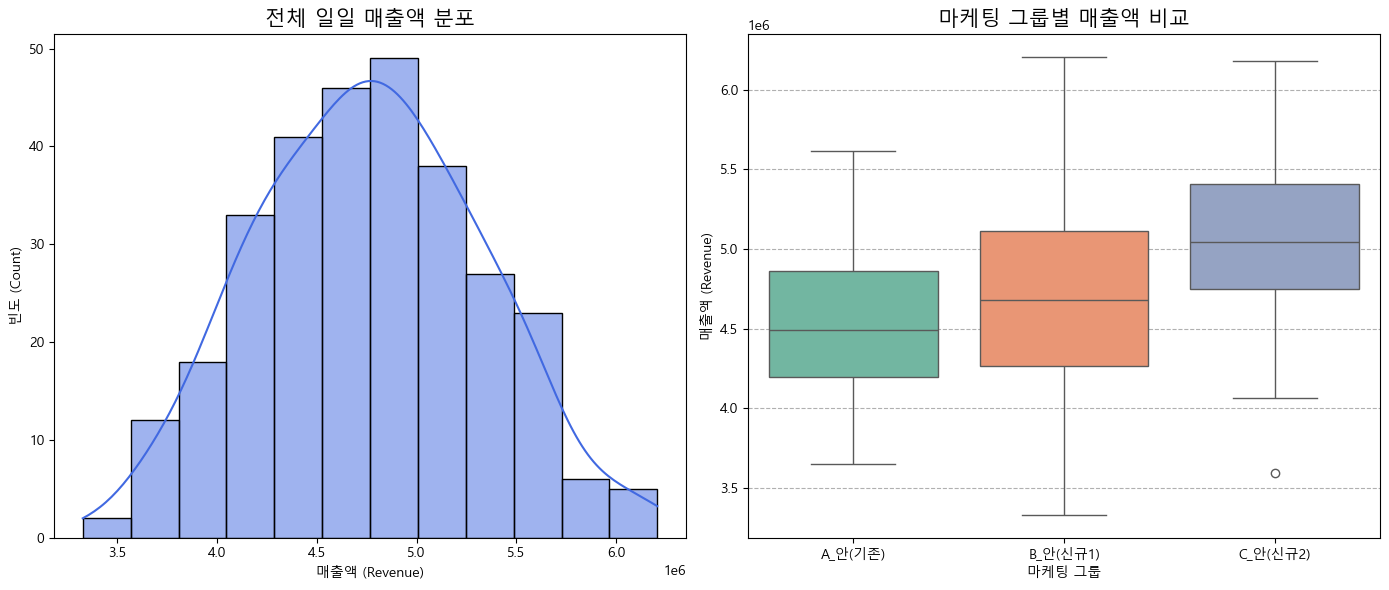

In [33]:
# fig: 그래프 객체
# axes: 축 객체
fig, axes = plt.subplots(1,2, figsize = (14,6)) # 1행2열 가로14,세로6

# [좌측그래프]
# histplot: seaborn 지원 히스토그램 함수
sns.histplot(
    data = df,          # DF
    x = "Revenue",      # x축에 들어갈 컬럼
    kde = True,         # 정규분포 선 추가
    color = "royalblue", 
    ax = axes[0]        # 차트가 위치할 축
)
axes[0].set_title("전체 일일 매출액 분포", fontsize = 15)   # axes[0] -> 첫번째 그래프에 title,xlabel,ylabel를 추가하겠다.
axes[0].set_xlabel("매출액 (Revenue)")
axes[0].set_ylabel("빈도 (Count)")

# [우측 그래프]
sns.boxplot(
    data = df,
    x = "Group",
    y = "Revenue",
    hue = "Group",      # x축 값들에 각기 다른 색상으로 표기 설정
    palette = "Set2",   # hue로 분리도니 각 그룹에 색상 세트 설정
                        # ('Set1', 'Set2', 'Pastel1', 'cpplwarm' 등)
    ax = axes[1]
)
axes[1].set_title("마케팅 그룹별 매출액 비교", fontsize = 15)   # axes[1] -> 두번째 그래프에 title,xlabel,ylabel를 추가하겠다.
axes[1].set_xlabel("마케팅 그룹")
axes[1].set_ylabel("매출액 (Revenue)")
axes[1].grid(axis = "y", linestyle = "--")

plt.tight_layout()
plt.show()

#### 그래프 해석
- `히스토그램`
    - 데이터가 한쪽으로 쏠려있지 않은 정규분포 형태이므로 통계 분석(t-test, ANOVA)을 진행하기에 아주 이상적이고 신뢰할 수 있는 상태
- `박스플롯`
    - A안(기준) - 로우 리스크 로우 리턴(성장 한계)으로 박스 위아래 수염 길이가 짧아 매일 비슷한 매출을 내는 안정성은 있지만, 박스플롯이 가장 아래쪽에 위치하여 성장의 한계가 명확함
    - B안(신규1) - 하이 리스크 하이 리턴(높은 변동성)으로 가장 극정인 성향을 보임, 박스의 위아래 수염길이가 각장 김, 즉 대박이 터지는 날은 C안 못지 않게 폭발적인 매출을 기록하지만 안 나오는 날은 기존 A안 보다도 한참 밑으로 떨어짐, 매출의 기복(불확실성)이 매우 큰 마케팅 안
    - C안(신규2) - 확실한 캐시카우(우상향)로 중앙값이 약 500만 부근으로 세 그룹 중 가낭 높음, 데이터의 50%가 모여있는 '박스' 전체가 다른 두 그룹 보다 높은 구간(약 470만~540만)에 형성되어 있음, 하단에 이상치가 하나 있긴 하지만 전박적인 매출 상승효과가 가장 뚜렷하고 강력

## 3. 가설 검정

### 1) 등분산 검정(Levene's test = 르벤검정)
- 두 집단의 데이터 퍼짐 정도(분산)가 비슷한지 확인하는 검정법
- t-test, ANOVA는 여러 집단의 평균을 그 분산에 비해서 비교 하므로 해당 검정 이전에 사전 확인을 위해서 등분산 검정을 사용함(필수는 아니나 미리 사전 파악용으로 종종 사용함)
- 귀무가설(H0): 두 집단의 분산은 같다.
- 대립가설(H1): 두 집단의 분산은 다르다.(p-value가 0.05보다 작으면 우연일 확률이 낮으므로 대립가설 채택)

In [44]:
group_a = df[df['Group'] == 'A_안(기존)']['Revenue']  # A안의 매출액    
group_b = df[df['Group'] == 'B_안(신규1)']['Revenue'] # B안의 매출액

var_a = np.var(group_a)
std_a = np.std(group_a)
var_b = np.var(group_b)
std_b = np.std(group_b)


print(f"▶ A안(기존) 분산: {var_a:,.0f} (표준편차): {std_a:,.0f}")
print(f"▶ B안(기존) 분산: {var_b:,.0f} (표준편차): {std_b:,.0f}")

▶ A안(기존) 분산: 204,347,167,264 (표준편차): 452,048
▶ B안(기존) 분산: 368,745,348,944 (표준편차): 607,244


In [46]:
# _ : 등분산 검정 통계량(현재는 몰라도 무방함)
# p_val : p-value 값
_, p_val = stats.levene(group_a,group_b)
print(f"▶ 유의확률(p-value):{p_val:,.4f}")

▶ 유의확률(p-value):0.0055


- `결과해석`: p-value가 0.05이하이므로 대립가설(두 집단의 분산이 다름)을 채택하게 되며 밑에 이어질 t-test 함수에서 두 분산이 다르다는 것을 설정해줘야함(equal_var = False)

### 2) T-test
- 두 집단(A안 vs B안)의 평균차이가 두 집단의 분산에 비해 통계적으로 유의미한지(신뢰할 수 있는지)검정
- 귀무가설: 두 집단의 평균의 차이가 없다.
- 대립가설: 두 집단에 유의미한 평균 차이가 있다.

In [49]:
# ttest_ind: 독립표본 t-test함수(ttest_rel: 대응표본 t-test함수)
# equal_var = False: 두 집단의 분산이 다르다고(=이분산) 가정(True는 분산이 같다고(=등분산) 가정)
_, p_val_t = stats.ttest_ind(group_a, group_b, equal_var = False)

print(f"▶ 유의확률(p-value):{p_val_t:,.4f}")
print(f"▶  - A안 평균 매출:{group_a.mean():,.0f}")
print(f"▶  - B안 평균 매출:{group_b.mean():,.0f}")

▶ 유의확률(p-value):0.0250
▶  - A안 평균 매출:4,530,056
▶  - B안 평균 매출:4,702,016


- `결과해석`: p-value가 0.05미만이므로, 두 그룹 같의 평균 매출 차이는 통계적으로 유의미함(차이가 있음)
- 단 현재 데이터는 3개의 안(A,B,C)이므로 사실 t-test가 아닌 ANOVA를 사용해야하며 현재는 t-test 적용 방법만 체크할 것
- `문제점`: 현재 A,B,C 총 3개의 안이 있으므로 t-test를 여러번 사용하면 되는거 아니냐고 생가할 수 있지만 이는 통계학에서 **다중 검정의 문제**를 발생시킴
    - p-value가 0.05인 t-test를 한 번 돌릴 때마다 5%의 리스크를 안고가는 것인데, 이를 여러번 돌리면 전체로 봤을 때 리스크의 총량은 커지게 됨
    - ex) 당첨 확률이 95%이고 꽝이 5%인 룰렛 게임을 수십차례 하다보면 결국 5% 짜리 꽝에 걸리게되는 것과 같음!
    - 따라서 3개 이상의 집단일 때는 이러한 리스크를 수학적으로 없앤 ANOVA분석을 사용함

### [실습] A안과 C안의 등분산 검정 및 t-test를 진행해서 결론을 도출해보세요
1) 등분산 검정: A안의 분산과 C안의 분산을 구하고 p-value값 구하기
2) t-test: p-value와 A,C 각각의 평균 매출 구하기
3) 결론 도출은 텍스트로 작성하기

In [52]:
# 1) 등분산 검정
group_a = df[df['Group'] == 'A_안(기존)']['Revenue']
group_c = df[df['Group'] == 'C_안(신규2)']['Revenue']


var_a = np.var(group_a)
var_c = np.var(group_c)

_, p_val2 = stats.levene(group_a,group_c)

print(f"▶ 유의확률(p-value):{p_val2:,.4f}")
print(f"▶ - A안(분산):{var_a:,.0f}")
print(f"▶ - C안(분산):{var_c:,.0f}")

▶ 유의확률(p-value):0.6168
▶ - A안(분산):204,347,167,264
▶ - C안(분산):236,111,419,499


In [70]:
# 2) t-test
_, p_val2_t = stats.ttest_ind(group_a, group_c, equal_var = True) # 등분산 검정에서 차이가 없다고 해서 equal_var = True라고 함

print(f"▶ 유의확률(p-value):{p_val2_t:,.4f}")
print(f"  - A안 평균 매출:{group_a.mean():,.0f}")
print(f"  - C안 평균 매출:{group_c.mean():,.0f}")

▶ 유의확률(p-value):0.0000
  - A안 평균 매출:4,530,056
  - C안 평균 매출:5,056,951


### 3) 결과 도출
- 등분산 검정시 유의확률이 0.05보다 크기 때문에 대립가설인 '분산의 차이가 있다' 는 것은 기각하고 귀무가설 채택
- t-test 진생시 유의확률이 0.05보다 작기 때문에 평균 매출은 '유의미한 차이가 있다'는 귀무가설을 채택하고 귀무가설을 기각

### 3) ANOVA
- 3개 이상 집단의 분산에 대한 평균차이 분석
- 단 차이가 있는지 없는지만 알 수 있고, 어떤 안이 얼마나 차이가 있는지는 알지 못해서 사후분석(Tukey)까지 진행해줘야함

In [72]:
_, p_val_f = stats.f_oneway(group_a, group_b, group_c)

print(f"▶ 유의확률(p-value):{p_val_f:,.4f}")
print(f"  - A안 평균 매출:{group_a.mean():,.0f}원")
print(f"  - B안 평균 매출:{group_b.mean():,.0f}원")
print(f"  - C안 평균 매출:{group_c.mean():,.0f}원")

▶ 유의확률(p-value):0.0000
  - A안 평균 매출:4,530,056원
  - B안 평균 매출:4,702,016원
  - C안 평균 매출:5,056,951원


- `결론`: p-value가 0.05미만이므로, 세 그룹 중 적어도 한 쌍 이상은 확실히 유의미하게 다른 평균 매출 수치를 보인다고 볼 수 있음

In [74]:
# pairwise_tukeyhsd: Tukey 사후 분석 함수
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [77]:
tukey_result = pairwise_tukeyhsd(
    endog = df["Revenue"],    # 결과 데이터
    groups = df["Group"],     # 구분할 기준
    alpha = 0.05              # 다중검정을 포함한 오차 허용 기준(5%)
)                             # 출력 결과에서 reject의 True, False를 가르는 기준

tukey_result.summary()
# meandiff: 두 그룹간 평균 차이
# p-adj: t-test의 다중검정 리스크를 보정한 p-value값
# Lower/upper: 9% 신뢰구간의 하한과 상한값
# reject: True는 두 그룹이 확실히 차이남, False는 차이가 크지 않거나 없다고 판단

group1,group2,meandiff,p-adj,lower,upper,reject
A_안(기존),B_안(신규1),171960.0,0.0533,-1921.5277,345841.5277,False
A_안(기존),C_안(신규2),526895.0,0.0,353013.4723,700776.5277,True
B_안(신규1),C_안(신규2),354935.0,0.0,181053.4723,528816.5277,True


#### - `결론`: C안의 reject가 True이면서 A안에 비해서도, B안에 비해서도 평균 매출이 높기 때문에 C안이 통계적으로 매출이 유의미하다.